In [ ]:
# Add library.
import librosa
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import soundfile as sf

In [23]:
# Read audio drone file path.
file_drone = f"../audio_file/Drone_high5m_25m.wav"

# Sample rate.
y_drone, sr_drone = librosa.load(file_drone, sr=None)

In [24]:
# Read audio natural file path.
file_natural = f"../audio_file/Naturalsound.wav"

# Sample rate.
y_natural, sr_natural = librosa.load(file_natural, sr=None)

In [25]:
# Short-Time Fourier Transform (STFT)
D_drone = np.abs(librosa.stft(y_drone))
D_natural = np.abs(librosa.stft(y_natural))

In [26]:
# Convert amplitude to decibel (dB)
DB_drone = librosa.amplitude_to_db(D_drone, ref=np.max)
DB_natural = librosa.amplitude_to_db(D_natural, ref=np.max)

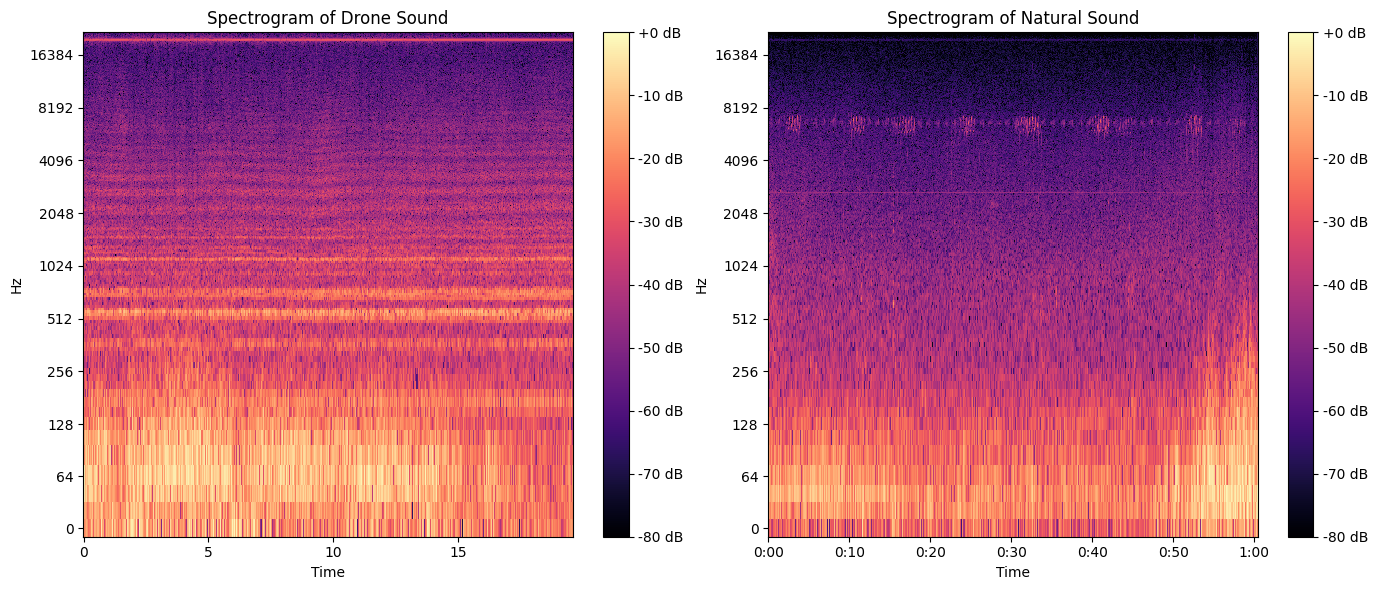

In [27]:
# Plot spectrogram

plt.figure(figsize=(14, 6))

# Plot spectrogram Drone.
plt.subplot(1, 2, 1)
librosa.display.specshow(DB_drone, sr=sr_drone, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Drone Sound')
plt.tight_layout()


# Plot spectrogram Natural.
plt.subplot(1, 2, 2)
librosa.display.specshow(DB_natural, sr=sr_natural, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Natural Sound')
plt.tight_layout()

plt.show()

In [28]:
# filter frequency (Hz)
low_band = 250 
high_band = 5000
order = 5

def bandpass_filter(data, sr, low_band, high_band, order):
    nyquist = 0.5 * sr
    low = low_band / nyquist
    high = high_band / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    y = signal.lfilter(b, a, data)
    return y


In [29]:
# Filtered drone and natural.
drone_filtered = bandpass_filter(y_drone, sr_drone, low_band, high_band, order)
nature_filtered = bandpass_filter(y_natural, sr_natural, low_band, high_band, order)

In [ ]:
# Short-Time Fourier Transform (STFT)
D_dronefil = np.abs(librosa.stft(drone_filtered))
D_naturefil = np.abs(librosa.stft(nature_filtered))

In [ ]:
# Convert amplitude to decibel (dB)
DB_dronefil = librosa.amplitude_to_db(D_dronefil, ref=np.max)
DB_naturefil = librosa.amplitude_to_db(D_naturefil, ref=np.max)

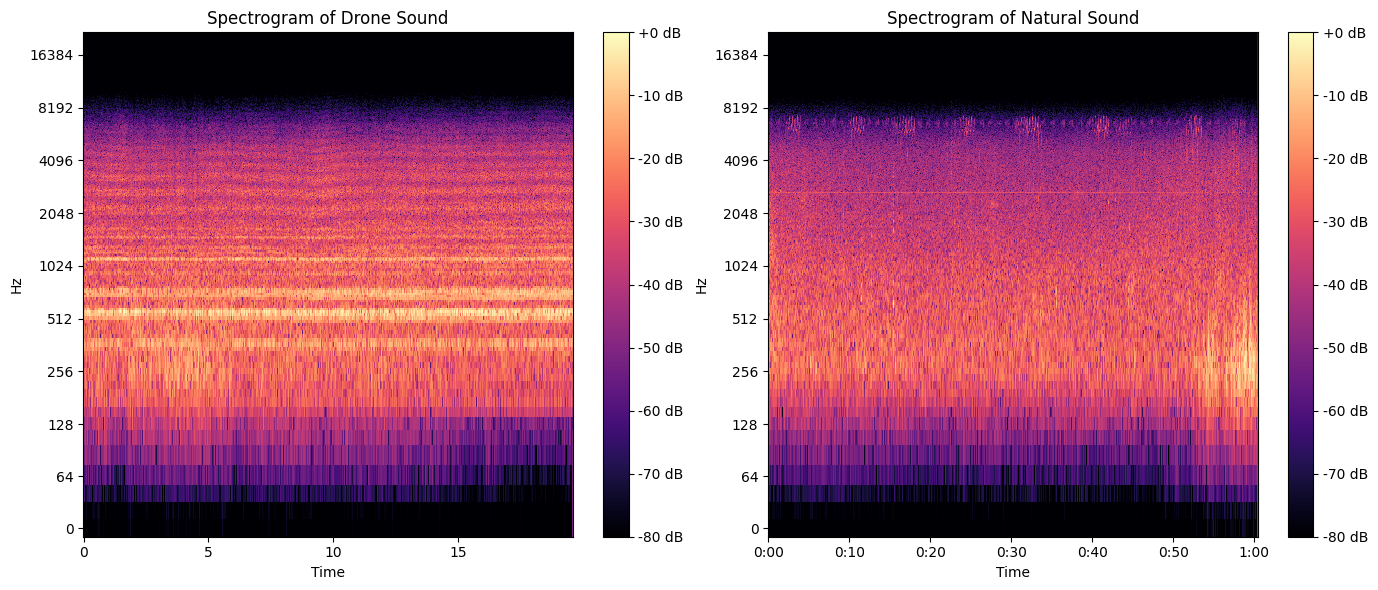

In [ ]:
# Plot spectrogram filtered

plt.figure(figsize=(14, 6))

# Plot spectrogram Drone filtered.
plt.subplot(1, 2, 1)
librosa.display.specshow(DB_dronefil, sr=sr_drone, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Drone filtered')
plt.tight_layout()


# Plot spectrogram Natural filtered.
plt.subplot(1, 2, 2)
librosa.display.specshow(DB_naturefil, sr=sr_natural, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram of Natural filtered')
plt.tight_layout()

plt.show()

In [ ]:
# magnitude และ phase
drone_mag, drone_phase = np.abs(D_drone), np.angle(D_drone)
noise_mag = np.mean(np.abs(D_natural), axis=1, keepdims=True)  # ค่าเฉลี่ยพลังงานของ noise

# --- ลบ noise spectrum ออกจาก drone spectrum ---
clean_mag = np.maximum(drone_mag - noise_mag, 0)

# --- แปลงกลับเป็นเสียง ---
clean_stft = clean_mag * np.exp(1j * drone_phase)
clean_audio = librosa.istft(clean_stft)